# Round 2: the tree per segment and per quarter

**Week 2, Monday. Notebook 2 of 3, round 2 of the morning.**

> "Every segment and channel." Anand Iyer, finance controller, Kalpa Retail, on what the Monday numbers must cover

Round 1 established that the warehouse is the book: its Q1 to Q2 fall is the 1.6 percent Week 1
defended, and Retail-Plus orders fall by the same third. Anand's sheet needs every leaf of the tree
for every segment in each quarter, which is eight rows of the same five numbers. Last week that
took a dictionary of running totals; here it is one clause, `GROUP BY`.

> **Kavya's review.** A ratio is only as honest as the two counts under it. Show me the orders and
> the customers beside every orders-per-customer figure, so I can divide them myself.

Four levels: groups in one query, the logical order a query runs in, a ratio the database rounds
without telling you, and a filter on groups.

**Setup.** The helper, the warehouse, and the named queries from
`../sql/C2_W02_D01_02_segments_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements, comments removed, for a block that runs more than one."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

Q = blocks("02_segments")
print(len(Q), "named queries read")

7 named queries read


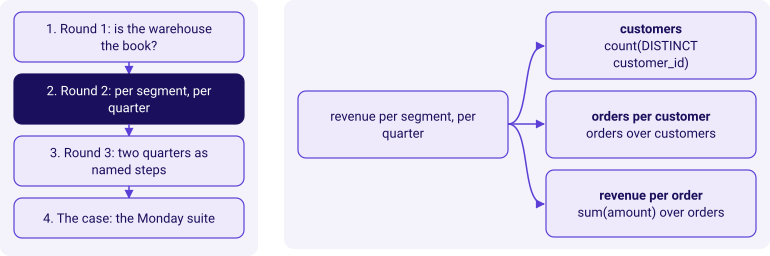

In [2]:
kit.side_by_side(
    kit.ladder(['Round 1: is the warehouse the book?', 'Round 2: per segment, per quarter', 'Round 3: two quarters as named steps', 'The case: the Monday suite'], lit=1, show=False),
    kit.driver_tree({"label": "revenue per segment, per quarter", "children": [
        {"label": "customers", "note": "count(DISTINCT customer_id)"},
        {"label": "orders per customer", "note": "orders over customers"},
        {"label": "revenue per order", "note": "sum(amount) over orders"}]}, show=False,
        width_per=210),
)

## 1. One query, one row per group

`GROUP BY quarter` collapses the thousand order rows into one row per quarter, and every aggregate
in the `SELECT` is computed within its group. Round 1 needed two queries for two quarters; this
needs one.

**Predict before you run.** How many rows does `GROUP BY quarter` return on the warehouse:
a) 1,000; b) 2; c) 6; d) 1?

quarter,orders,revenue
Q1,538,"100,000,000"
Q2,462,"98,400,000"


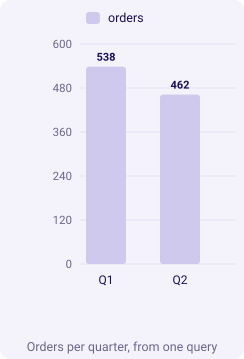

In [3]:
byq = kit.sql(Q["r2_by_quarter"])
kit.sql_table(Q["r2_by_quarter"], caption="GROUP BY quarter: one row per quarter")
kit.columns(["Q1", "Q2"], [("orders", [int(r["orders"]) for r in byq])],
            title="Orders per quarter, from one query")
kit.check("GROUP BY quarter returns one row per quarter", len(byq) == 2, f"{len(byq)} rows")
kit.check("the groups add back to the book", sum(int(r["orders"]) for r in byq) == 1000)

**What happened.** The answer is b: two rows, and their orders add back to 1,000. A group query
that does not add back to the table it grouped has lost or doubled rows, and that sum is the first
check on any grouped result.

## 2. The logical order, and the error worth two minutes

The database reads a query in a different order from the one it is written in: `FROM` first, then
`WHERE`, `GROUP BY`, `HAVING`, `SELECT`, `ORDER BY` and last `LIMIT`. Anand's analyst reads it in
that order too, and most beginner errors are explained by it.

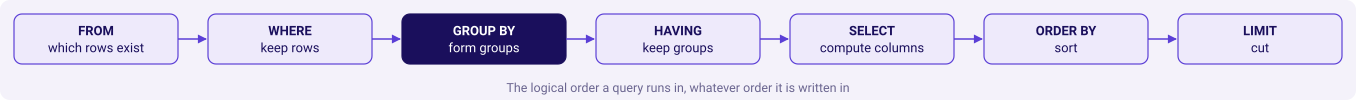

In [4]:
kit.flow(["FROM\nwhich rows exist", "WHERE\nkeep rows", "GROUP BY\nform groups",
          "HAVING\nkeep groups", "SELECT\ncompute columns", "ORDER BY\nsort", "LIMIT\ncut"],
         lit=2, title="The logical order a query runs in, whatever order it is written in")

The error below is met once, read from its last line, and fixed. It is two minutes, never a
lesson: the query asks for a segment per group while grouping only by quarter, so each quarter
group holds four segments and the database refuses to pick one.

In [5]:
bad = """SELECT c.segment, o.quarter, count(*) AS orders
FROM orders o JOIN customers c USING (customer_id)
GROUP BY o.quarter"""
with kit.expect_error() as err:
    kit.sql(bad)
kit.check("the database refuses a column that is neither grouped nor aggregated",
          err.name == "GroupingError", err.name)

Two fixes exist: add `c.segment` to `GROUP BY`, which is what Anand asked for, or wrap it in an
aggregate, which answers a different question. The first fix gives the eight-row table.

**Predict before you run.** Four segments, two quarters. How many rows: a) 4; b) 8; c) 2; d) 1,000?

In [6]:
print(Q["r2_segment_quarter"])

-- The question: orders, customers who bought and revenue, per segment per quarter.
SELECT c.segment,
       o.quarter,
       count(*)                      AS orders,
       count(DISTINCT o.customer_id) AS customers,
       sum(o.amount)                 AS revenue
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment, o.quarter
ORDER  BY c.segment, o.quarter;


segment,quarter,orders,customers,revenue
Business,Q1,97,36,"99,014,440"
Business,Q2,91,35,"97,584,600"
Retail-Core,Q1,199,102,"373,070"
Retail-Core,Q2,193,96,"366,250"
Retail-Plus,Q1,215,91,"585,770"
Retail-Plus,Q2,140,76,"413,380"
Student,Q1,27,15,"26,720"
Student,Q2,38,20,"35,770"


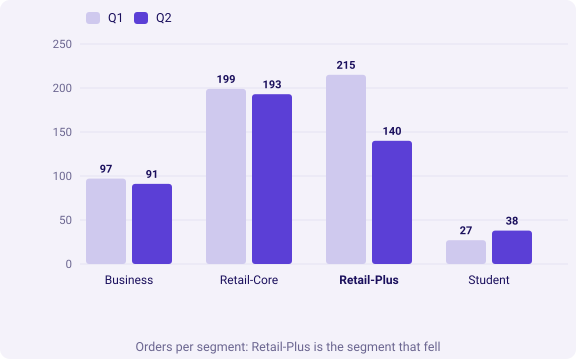

In [7]:
seg = kit.sql(Q["r2_segment_quarter"])
kit.sql_table(Q["r2_segment_quarter"], caption="Orders, customers and revenue per segment per quarter")
names = ["Business", "Retail-Core", "Retail-Plus", "Student"]
kit.columns(names, [("Q1", [int(r["orders"]) for r in seg if r["quarter"] == "Q1"]),
                    ("Q2", [int(r["orders"]) for r in seg if r["quarter"] == "Q2"])],
            title="Orders per segment: Retail-Plus is the segment that fell", lit=(2,))
kit.check("eight rows, one per segment and quarter", len(seg) == 8)
kit.check("the eight groups add back to 1,000 orders", sum(int(r["orders"]) for r in seg) == 1000)

**What happened.** The answer is b. Retail-Plus falls from 215 orders to 140, and every other
segment holds roughly level. The table is the tree's first two leaves per segment; the third leaf,
orders per customer, is a division, and that is where the round's trap sits.

## 3. The plausible wrong answer: a ratio the database rounded without saying so

Anand's sheet needs orders per customer for every segment and quarter, the frequency branch Week 1
told Meera to fix.

**Predict before you run.** `count(*) / count(DISTINCT customer_id)` for Retail-Plus in Q2, with
140 orders from 76 customers. What does Postgres return: a) 1.84; b) 1; c) 2; d) an error?

In [8]:
print(Q["r2_frequency_hurried"])

-- The question: orders per customer, per segment per quarter. (The hurried version.)
SELECT c.segment,
       o.quarter,
       count(*) / count(DISTINCT o.customer_id) AS orders_per_customer
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment, o.quarter
ORDER  BY c.segment, o.quarter;


segment,quarter,orders_per_customer
Business,Q1,2
Business,Q2,2
Retail-Core,Q1,1
Retail-Core,Q2,2
Retail-Plus,Q1,2
Retail-Plus,Q2,1
Student,Q1,1
Student,Q2,1


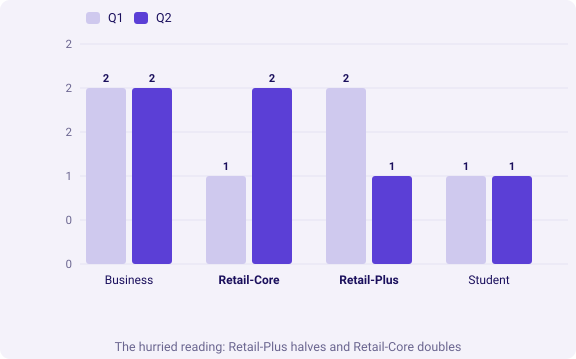

In [9]:
hurried = kit.sql(Q["r2_frequency_hurried"])
kit.sql_table(Q["r2_frequency_hurried"], caption="The hurried frequency, as it would reach the sheet")
h = {(r["segment"], r["quarter"]): int(r["orders_per_customer"]) for r in hurried}
kit.columns(names, [("Q1", [h[(n, "Q1")] for n in names]), ("Q2", [h[(n, "Q2")] for n in names])],
            title="The hurried reading: Retail-Plus halves and Retail-Core doubles", lit=(1, 2))

**The plausible wrong answer.** Retail-Plus members went from 2 orders a quarter to 1, so
frequency halved; Retail-Core went from 1 to 2, so frequency doubled. Read aloud to the head of
Retail-Plus, it says her members now order once a quarter, and it says the loyalty budget should
follow Retail-Core, whose members suddenly order twice as often.

**Why it is wrong.** `count(*)` and `count(DISTINCT ...)` both return integers, and Postgres
divides two integers as integers, dropping the fraction. 140 over 76 is 1.84, and the query
printed 1. The answer is b. Nothing warned you; the column looks like any other number.

**The check that exposes it.** Multiply the ratio back by the customers. If the ratio were right,
it would give the orders.

segment,quarter,orders,customers,hurried_ratio,orders_it_implies
Business,Q1,97,36,2,72
Business,Q2,91,35,2,70
Retail-Core,Q1,199,102,1,102
Retail-Core,Q2,193,96,2,192
Retail-Plus,Q1,215,91,2,182
Retail-Plus,Q2,140,76,1,76
Student,Q1,27,15,1,15
Student,Q2,38,20,1,20


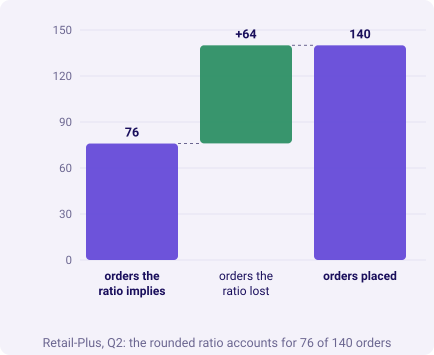

In [10]:
chk = kit.sql(Q["r2_frequency_check"])
kit.sql_table(Q["r2_frequency_check"], caption="Ratio times customers should give the orders; it does not")
plus_q2 = next(r for r in chk if r["segment"] == "Retail-Plus" and r["quarter"] == "Q2")
kit.bridge(("orders the ratio implies", int(plus_q2["orders_it_implies"])),
           [("orders the ratio lost", int(plus_q2["orders"]) - int(plus_q2["orders_it_implies"]))],
           end_label="orders placed", fmt=lambda v: f"{v:,.0f}",
           title="Retail-Plus, Q2: the rounded ratio accounts for 76 of 140 orders")
kit.check("the hurried ratio does not multiply back in any row",
          sum(1 for r in chk if r["orders_it_implies"] != r["orders"]) == 8, "8 of 8 rows")
kit.check("Retail-Plus Q2 reads 1 in integers", h[("Retail-Plus", "Q2")] == 1)

In [11]:
print(Q["r2_frequency_fixed"])

-- The fix: make one side numeric before dividing, then round for the reader.
SELECT c.segment,
       o.quarter,
       round(count(*)::numeric / count(DISTINCT o.customer_id), 2) AS orders_per_customer,
       round(sum(o.amount) / count(*))                            AS revenue_per_order
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment, o.quarter
ORDER  BY c.segment, o.quarter;


segment,quarter,orders_per_customer,revenue_per_order
Business,Q1,2.69,"1,020,767"
Business,Q2,2.6,"1,072,358"
Retail-Core,Q1,1.95,1875
Retail-Core,Q2,2.01,1898
Retail-Plus,Q1,2.36,2725
Retail-Plus,Q2,1.84,2953
Student,Q1,1.8,990
Student,Q2,1.9,941


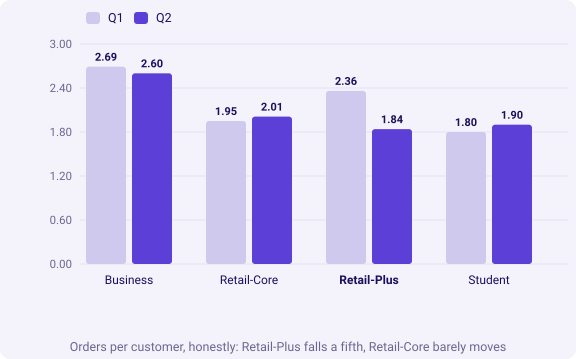

In [12]:
fixed = kit.sql(Q["r2_frequency_fixed"])
kit.sql_table(Q["r2_frequency_fixed"], caption="The fix: numeric division, rounded for the reader")
f = {(r["segment"], r["quarter"]): float(r["orders_per_customer"]) for r in fixed}
kit.columns(names, [("Q1", [f[(n, "Q1")] for n in names]), ("Q2", [f[(n, "Q2")] for n in names])],
            title="Orders per customer, honestly: Retail-Plus falls a fifth, Retail-Core barely moves",
            fmt=lambda v: f"{v:.2f}", lit=(2,))
kit.check("Retail-Plus falls from 2.36 to 1.84", (f[("Retail-Plus", "Q1")], f[("Retail-Plus", "Q2")]) == (2.36, 1.84))
kit.check("Retail-Core moves from 1.95 to 2.01, far from doubling",
          (f[("Retail-Core", "Q1")], f[("Retail-Core", "Q2")]) == (1.95, 2.01))

**The fix, and what it changed.** `count(*)::numeric / count(DISTINCT customer_id)` makes one side
numeric, so the division keeps its fraction, and `round(..., 2)` rounds for the reader on purpose.
Retail-Plus frequency falls 22 percent, from 2.36 to 1.84, where the hurried sheet said it halved;
Retail-Core rises 3 percent, from 1.95 to 2.01, where the hurried sheet said it doubled. The
decision flips back: Retail-Plus is the segment to fix, and no budget moves to Retail-Core.

## 4. Filtering groups: WHERE runs before GROUP BY, HAVING runs after

Week 1 Thursday warned against a rate built on twelve orders. The suite should flag any
segment-quarter too thin to read a rate from. The count exists only after grouping, so the filter
has to run after `GROUP BY`, which is what `HAVING` is for. `WHERE count(*) < 30` fails, because
`WHERE` runs before any group exists.

**Predict before you run.** How many of the eight segment-quarters hold fewer than 30 orders:
a) none; b) one; c) two; d) four?

In [13]:
print(Q["r2_thin_cells"])

-- The question: which segment-quarters hold fewer than 30 orders, too few to read a rate from?
-- WHERE filters rows before they are grouped; HAVING filters the groups after.
SELECT c.segment, o.quarter, count(*) AS orders
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment, o.quarter
HAVING count(*) < 30
ORDER  BY orders;


segment,quarter,orders
Student,Q1,27


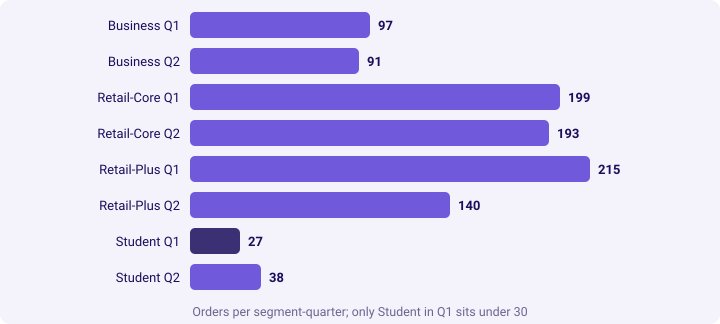

In [14]:
thin = kit.sql(Q["r2_thin_cells"])
kit.sql_table(Q["r2_thin_cells"], caption="HAVING count(*) < 30: the groups too thin for a rate")
kit.bars([(f"{r['segment']} {r['quarter']}", int(r["orders"])) for r in seg], lit=(6,),
         title="Orders per segment-quarter; only Student in Q1 sits under 30")
kit.check("one segment-quarter holds fewer than 30 orders", len(thin) == 1,
          f"{thin[0]['segment']} {thin[0]['quarter']}: {thin[0]['orders']}")

**What happened.** The answer is b: Student in Q1, with 27 orders. Its orders per customer carries
a warning on Anand's sheet.

**The harder variant.** The room runs the same tree on delivered orders only. The status filter
works on rows, so it is a `WHERE`, and it runs before the groups form.

segment,quarter,orders,customers,orders_per_customer,revenue
Business,Q1,57,30,1.9,"67,348,440"
Business,Q2,54,26,2.08,"66,030,600"
Retail-Core,Q1,135,86,1.57,"252,030"
Retail-Core,Q2,127,73,1.74,"245,340"
Retail-Plus,Q1,144,77,1.87,"405,110"
Retail-Plus,Q2,89,57,1.56,"262,580"
Student,Q1,19,12,1.58,"19,620"
Student,Q2,28,17,1.65,"26,570"


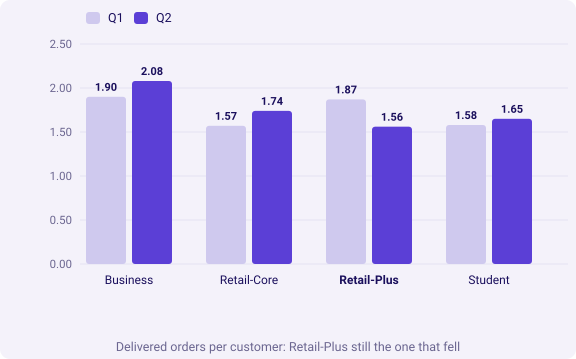

In [15]:
dl = kit.sql(Q["r2_delivered_by_segment"])
kit.sql_table(Q["r2_delivered_by_segment"], caption="The tree per segment and quarter, delivered orders only")
d = {(r["segment"], r["quarter"]): float(r["orders_per_customer"]) for r in dl}
kit.columns(names, [("Q1", [d[(n, "Q1")] for n in names]), ("Q2", [d[(n, "Q2")] for n in names])],
            title="Delivered orders per customer: Retail-Plus still the one that fell",
            fmt=lambda v: f"{v:.2f}", lit=(2,))
kit.check("delivered orders are a subset of the book", sum(int(r["orders"]) for r in dl) == 653)
kit.check("on delivered orders Retail-Plus frequency still falls", d[("Retail-Plus", "Q2")] < d[("Retail-Plus", "Q1")],
          f"{d[('Retail-Plus', 'Q1')]} to {d[('Retail-Plus', 'Q2')]}")

> **Kavya's review.** Every ratio on this sheet now sits beside the two counts it divides, so the
> analyst can check it with a calculator. Say in the comment which orders count, booked or
> delivered, and flag the thin cell rather than hiding it.

### In the interview

**[S] WHERE against HAVING, one sentence each.** "`WHERE` filters rows before they are grouped,
so it can only test columns of a row. `HAVING` filters groups after `GROUP BY`, so it can test an
aggregate like `count(*)`. If a condition could go in either, like a segment name, I put it in
`WHERE`, because it throws rows away before the work of grouping them."

**[S] Explain the logical order in which a SQL query executes.** "`FROM` and any joins build the
rows, `WHERE` keeps some, `GROUP BY` forms groups, `HAVING` keeps some groups, `SELECT` computes
the output columns, `DISTINCT` removes duplicates, `ORDER BY` sorts and `LIMIT` cuts. That order
explains the classic errors: why an alias from `SELECT` cannot be used in `WHERE`, why `WHERE
count(*)` fails, and why a column must be grouped or aggregated."

A strong candidate adds that this is the logical order; the planner may execute differently as long
as the result is the same.

### Depth: why Postgres divides integers as integers

Postgres follows the SQL rule that an operation on two integers returns an integer, so `140 / 76`
is `1` and `7 / 2` is `3`. Casting either side (`::numeric`, or multiplying by `1.0`) keeps the
fraction. pandas and Python 3 divide the other way, which is why a query copied from a notebook's
logic can change a number without an error.

In [16]:
demo = kit.sql("SELECT 140 / 76 AS integers, round(140::numeric / 76, 2) AS numeric_division, 7 / 2 AS seven_halves")[0]
kit.table(["expression", "result"], [("140 / 76", demo["integers"]), ("140::numeric / 76", demo["numeric_division"]),
                                     ("7 / 2", demo["seven_halves"])], caption="The same division, two types")
kit.check("integer division drops the fraction", demo["integers"] == 1 and demo["seven_halves"] == 3)

expression,result
140 / 76,1
140::numeric / 76,1.84
7 / 2,3


In [17]:
kit.check_summary()
print("Next: round 3, the two quarters side by side as named steps.")

Next: round 3, the two quarters side by side as named steps.
